In [2]:
import torch
import torch.nn as nn
import timm
from ultralytics import YOLO
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---- Load EfficientNet ----
class FruitQualityClassifier(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnetv2_s", pretrained=False,
            num_classes=0, global_pool="avg"
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.backbone.num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 6)
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))

classifier = FruitQualityClassifier().to(DEVICE)
classifier.load_state_dict(torch.load(
    "/content/drive/MyDrive/agri_weights/efficientnet_best.pth",
    map_location=DEVICE
))
classifier.eval()
print("✅ Classifier loaded!")

# ---- Load YOLOv8 ----
detector = YOLO("/content/drive/MyDrive/agri_weights/yolov8_defect/weights/best.pt")
print("✅ Detector loaded!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Classifier loaded!
✅ Detector loaded!


In [3]:
CLASS_NAMES = [
    'freshapples', 'freshbanana', 'freshoranges',
    'rottenapples', 'rottenbanana', 'rottenoranges'
]

QUALITY_MAP = {
    'freshapples': 'fresh', 'freshbanana': 'fresh', 'freshoranges': 'fresh',
    'rottenapples': 'rotten', 'rottenbanana': 'rotten', 'rottenoranges': 'rotten'
}

val_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
import os
from groq import Groq
from dotenv import load_dotenv

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY", "")
groq_client = Groq(api_key=GROQ_API_KEY)

def get_advice(clf_result, det_result):
    prompt = f"""
Kết quả phân tích nông sản:
- Loại: {clf_result['label']} (độ tin cậy: {clf_result['confidence']}%)
- Chất lượng: {clf_result['quality']}
- Số vùng khuyết tật: {det_result['num_defects']}
- Chi tiết: {[d['class'] for d in det_result['detections']]}

Hãy tư vấn ngắn gọn cho nông dân về sản phẩm này (3-4 câu tiếng Việt):
1. Đánh giá chất lượng
2. Khuyến nghị xử lý (bảo quản / xuất bán / loại bỏ)
"""
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
        temperature=0.7
    )
    return response.choices[0].message.content

print("✅ Groq LLM ready!")

✅ Groq LLM ready!


In [13]:
def analyze_fruit(image_path):
    image = Image.open(image_path).convert("RGB")

    # 1. Classify
    tensor = val_transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = classifier(tensor)
        probs = torch.softmax(out, dim=1)[0]
        conf, idx = probs.max(0)
    clf_result = {
        "label":      CLASS_NAMES[idx.item()],
        "quality":    QUALITY_MAP[CLASS_NAMES[idx.item()]],
        "confidence": round(conf.item() * 100, 2)
    }

    # 2. Detect
    img_np   = np.array(image)
    det_out  = detector(img_np, conf=0.25, verbose=False)[0]
    det_result = {
        "num_defects": len(det_out.boxes),
        "detections": [
            {"class": det_out.names[int(b.cls)], "conf": round(float(b.conf)*100, 2)}
            for b in det_out.boxes
        ]
    }

    # 3. LLM advice
    advice = get_advice(clf_result, det_result)

    return clf_result, det_result, advice, det_out.plot()

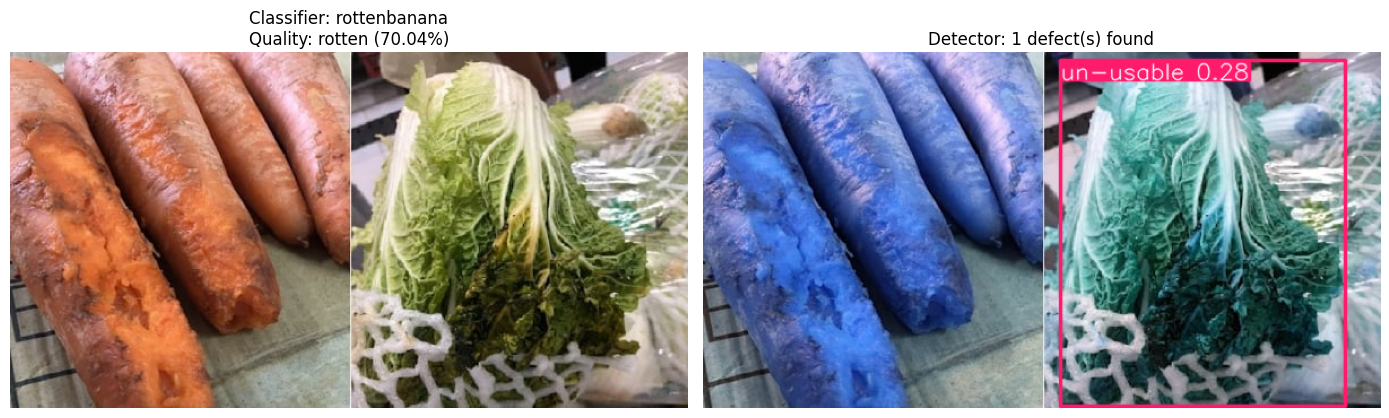


🤖 LLM Advice:
Tôi khuyên nông dân nên đánh giá chất lượng sản phẩm này là không tốt do chất lượng là "rotten".

Tôi khuyên nông dân nên loại bỏ sản phẩm này vì đã bị hư hỏng và không thể sử dụng được. Việc bảo quản không thể giúp cải thiện chất lượng sản phẩm, và xuất bán sẽ ảnh hưởng đến uy tín và danh dự của nông dân.


In [14]:
import os, shutil

# Đổi tên file thành tên đơn giản không dấu
old_path = list(uploaded.keys())[0]
new_path = "test_fruit.jpg"
shutil.copy(old_path, new_path)

# Chạy pipeline với tên mới
clf, det, advice, annotated = analyze_fruit(new_path)

# Hiển thị kết quả
fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0])
ax1.imshow(Image.open(new_path))
ax1.set_title(f"Classifier: {clf['label']}\nQuality: {clf['quality']} ({clf['confidence']}%)", fontsize=12)
ax1.axis("off")

ax2 = fig.add_subplot(gs[1])
ax2.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
ax2.set_title(f"Detector: {det['num_defects']} defect(s) found", fontsize=12)
ax2.axis("off")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/agri_weights/pipeline_demo.png", dpi=150)
plt.show()

print("\n" + "="*50)
print("🤖 LLM Advice:")
print("="*50)
print(advice)

In [15]:
# Lưu text kết quả
with open("/content/drive/MyDrive/agri_weights/demo_result.txt", "w") as f:
    f.write(f"Label: {clf['label']}\n")
    f.write(f"Quality: {clf['quality']}\n")
    f.write(f"Confidence: {clf['confidence']}%\n")
    f.write(f"Defects: {det['num_defects']}\n")
    f.write(f"\nLLM Advice:\n{advice}\n")

print("✅ Kết quả đã lưu vào Drive!")
print("📁 /content/drive/MyDrive/agri_weights/demo_result.txt")
print("🖼️  /content/drive/MyDrive/agri_weights/pipeline_demo.png")

✅ Kết quả đã lưu vào Drive!
📁 /content/drive/MyDrive/agri_weights/demo_result.txt
🖼️  /content/drive/MyDrive/agri_weights/pipeline_demo.png
